
# 03 · Embeddings **No Contextuales** (Word2Vec & FastText)



## 1. Configuración

Entrenamos los modelos Word2Vec con vectores de 300 dimensiones, una ventana de contexto de tamaño 5 y un `min_count=5` para eliminar términos poco frecuentes que no aportan valor semántico. Escogimos 300 dimensiones como valor de referencia habitual en la literatura, ya que ofrece un equilibrio adecuado entre capacidad representativa y coste computacional. La ventana de 5 permite capturar relaciones de co-ocurrencia locales propias del lenguaje financiero sin introducir ruido de contexto excesivo.



In [ ]:
INPUT_DATA_PATH = "datasPost_prepro/preprocNoContext.parquet"
TEXT_COLUMN = "noContextText"
OUTPUT_DIR = "embeddings/NoContext"

RANDOM_SEED = 42
VECTOR_SIZE = 300
WINDOW = 5
MIN_COUNT = 5
WORKERS = 4
EPOCHS = 10 

USE_BIGRAMS = True
PHRASES_MIN_COUNT = 10
PHRASES_THRESHOLD = 10.0


In [3]:

import os
import re
import math
import random
import numpy as np
import pandas as pd

from gensim.models import Word2Vec, FastText
from gensim.models.phrases import Phrases, Phraser

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)


## 3. Carga del dataset

In [4]:

# Carga flexible: parquet o csv
def load_corpus(path, text_col):
    if path.endswith(".parquet"):
        df = pd.read_parquet(path)
    elif path.endswith(".csv"):
        df = pd.read_csv(path)
    else:
        raise ValueError("Formato no soportado. Usa .parquet o .csv")
    if text_col not in df.columns:
        raise KeyError(f"La columna '{text_col}' no existe en el dataset. Columnas disponibles: {list(df.columns)[:10]}...")
    return df[[text_col]].dropna().rename(columns={text_col: "text"})

df = load_corpus(INPUT_DATA_PATH, TEXT_COLUMN)
print("Registros:", len(df))
df.head(3)


Registros: 5160


,text
0,uk job market continue sign weakness pay growt...
1,new datum department work pension work pattern...
2,ask workplace accommodation easy people worry ...


## 4. Tokenización ligera

In [5]:

def simple_tokenize(s):
    toks = [t for t in s.split() if t]
    return toks

sentences_tokens = df["text"].map(simple_tokenize).tolist()
print("Ejemplo de tokens:", sentences_tokens[0][:30] if len(sentences_tokens)>0 else [])


Ejemplo de tokens: ['uk', 'job', 'market', 'continue', 'sign', 'weakness', 'pay', 'growth', 'slowing', 'unemployment', 'edge', 'higher', 'ahead', 'autumn', 'budget', 'month', 'late', 'datum', 'office', 'national', 'statistic', 'ons', 'release', 'tuesday', 'annual', 'wage', 'growth', 'exclude', 'bonus', 'in']


## 5. Detección de bigramas (opcional)

In [6]:

if USE_BIGRAMS:
    phrases = Phrases(
    sentences_tokens,
    min_count=PHRASES_MIN_COUNT,
    threshold=PHRASES_THRESHOLD,
    delimiter="_"   # <- en vez de b"_"
    )

    bigram = Phraser(phrases)
    sentences_tokens = [bigram[sent] for sent in sentences_tokens]
    print("Bigramas aplicados. Ejemplo:", sentences_tokens[0][:30] if len(sentences_tokens)>0 else [])
else:
    print("Bigramas desactivados.")


Bigramas aplicados. Ejemplo: ['uk', 'job', 'market', 'continue', 'sign', 'weakness', 'pay', 'growth', 'slowing', 'unemployment', 'edge', 'higher', 'ahead', 'autumn_budget', 'month', 'late', 'datum', 'office', 'national_statistic', 'ons', 'release', 'tuesday', 'annual', 'wage', 'growth', 'exclude', 'bonus', 'in', 'month', 'august']


Vemos que se guardan relaciones de bigramas, buena señal de momento. Porque guardamos relaciones como autumn_budget

## 6. Entrenamiento de modelos

Hemos decidido probar ambas arquitecturas CBOW y Skip-gram para comparar su comportamiento. CBOW comunmente es más eficiente y tiende a representar bien palabras frecuentes, mientras que Skip-gram es más preciso para términos poco comunes, algo especialmente relevante en un corpus financiero donde aparecen nombres y acrónimos con baja frecuencia.


In [7]:

# Word2Vec CBOW
w2v_cbow = Word2Vec(
    sentences=sentences_tokens,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=0,  # CBOW
    epochs=EPOCHS,
    seed=RANDOM_SEED
)

# Word2Vec Skip-gram
w2v_sg = Word2Vec(
    sentences=sentences_tokens,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=1,  # Skip-gram
    epochs=EPOCHS,
    seed=RANDOM_SEED
)

# FastText (skip-gram por defecto en gensim si sg=1)
ft_sg = FastText(
    sentences=sentences_tokens,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=1,
    epochs=EPOCHS,
    seed=RANDOM_SEED
)

# Guardado de modelos
w2v_cbow_path = os.path.join(OUTPUT_DIR, "w2v_cbow.model")
w2v_sg_path   = os.path.join(OUTPUT_DIR, "w2v_sg.model")
ft_sg_path    = os.path.join(OUTPUT_DIR, "fasttext_sg.model")

w2v_cbow.save(w2v_cbow_path)
w2v_sg.save(w2v_sg_path)
ft_sg.save(ft_sg_path)

print("Modelos guardados en:")
print(" -", w2v_cbow_path)
print(" -", w2v_sg_path)
print(" -", ft_sg_path)


Modelos guardados en:
 - embeddings/NoContext\w2v_cbow.model
 - embeddings/NoContext\w2v_sg.model
 - embeddings/NoContext\fasttext_sg.model


## 7. Cobertura, vocabulario y OOV

In [8]:

def corpus_vocab_and_oov(sentences, kv):
    vocab = set(kv.key_to_index.keys())
    total_tokens = 0
    in_vocab = 0
    for sent in sentences:
        for tok in sent:
            total_tokens += 1
            if tok in vocab:
                in_vocab += 1
    oov = total_tokens - in_vocab
    return {
        "unique_vocab_model": len(vocab),
        "total_tokens_corpus": total_tokens,
        "in_vocab_tokens": in_vocab,
        "oov_tokens": oov,
        "oov_pct": 100.0 * oov / max(total_tokens, 1)
    }

stats = {
    "w2v_cbow": corpus_vocab_and_oov(sentences_tokens, w2v_cbow.wv),
    "w2v_sg": corpus_vocab_and_oov(sentences_tokens, w2v_sg.wv),
    "ft_sg": corpus_vocab_and_oov(sentences_tokens, ft_sg.wv),
}
pd.DataFrame(stats).T


,unique_vocab_model,total_tokens_corpus,in_vocab_tokens,oov_tokens,oov_pct
w2v_cbow,12367.0,1178892.0,1154050.0,24842.0,2.107233
w2v_sg,12367.0,1178892.0,1154050.0,24842.0,2.107233
ft_sg,12367.0,1178892.0,1154050.0,24842.0,2.107233


## 8. Ejemplos de similitud y analogías

En esta fase entrenamos distintos modelos de embeddings no contextuales con una misma configuración para poder comparar su comportamiento. Mantenemos los mismos parámetros principales (tamaño de vector, ventana, número de épocas, etc.) y aplicamos el entrenamiento sobre el mismo corpus financiero. Nuestro objetivo es evaluar qué modelo Word2Vec, FastText o GloVe genera representaciones más coherentes y adaptadas al dominio económico, tanto en cobertura léxica como en organización semántica.


In [9]:

EXAMPLES = [
    "market", "stock", "revenue", "profit", "ai", "inflation", "nasdaq", 
    "federal_reserve", "interest_rate", "shareholders"
]

def try_most_similar(model, words, topn=10):
    out = {}
    for w in words:
        try:
            out[w] = model.wv.most_similar(w, topn=topn)
        except KeyError:
            out[w] = [("**OOV**", 0.0)]
    return out

print("Word2Vec CBOW similitudes:")
sim_cbow = try_most_similar(w2v_cbow, EXAMPLES, topn=10)
for w, lst in sim_cbow.items():
    print(f"\n{w}:")
    for t, s in lst[:10]:
        print("  ", t, f"{s:.3f}")

print("\nWord2Vec SG similitudes:")
sim_sg = try_most_similar(w2v_sg, EXAMPLES, topn=10)
for w, lst in sim_sg.items():
    print(f"\n{w}:")
    for t, s in lst[:10]:
        print("  ", t, f"{s:.3f}")

print("\nFastText SG similitudes:")
sim_ft = try_most_similar(ft_sg, EXAMPLES, topn=10)
for w, lst in sim_ft.items():
    print(f"\n{w}:")
    for t, s in lst[:10]:
        print("  ", t, f"{s:.3f}")


Word2Vec CBOW similitudes:

market:
   space 0.433
   poise 0.411
   landscape 0.405
   sector 0.404
   somewhat 0.365
   remain 0.363
   europe 0.358
   trade_desk 0.350
   firmly 0.341
   breakneck 0.338

stock:
   arguably 0.544
   decent 0.529
   magnificent_seven 0.522
   mega_cap 0.522
   palantir 0.511
   surprising 0.510
   remarkable 0.505
   share 0.492
   buy_hold 0.492
   writing 0.491

revenue:
   annual_revenue 0.739
   total_revenue 0.734
   operating_profit 0.675
   annualize_revenue 0.663
   net_income 0.651
   operating_income 0.649
   net_sale 0.627
   operate_income 0.625
   profit 0.607
   arr 0.604

profit:
   cash_flow 0.683
   operating_profit 0.676
   profit_margin 0.664
   operate_income 0.643
   backlog 0.631
   profitability 0.623
   double_digit 0.616
   fcf 0.613
   total_revenue 0.609
   revenue 0.607

ai:
   generative_ai 0.689
   artificial_intelligence 0.648
   ai_revolution 0.580
   cloud_computing 0.475
   powerful 0.470
   ai_boom 0.468
   generativ

### 8.1 Analogías (a - b + c)

Queremos hacer pruebas de analogías para evaluar si los embeddings capturan correctamente relaciones semánticas y sintácticas entre palabras del dominio. Vamos a ver como reproducen patrones lógicos del tipo *a - b + c*, como *bear → bearish → bullish* o *economy → inflation → deflation*, lo que indicaría que han aprendido estructuras de significado coherentes. Estas pruebas nos permiten comparar la calidad semántica de Word2Vec y FastText más allá de la simple similitud léxica.


In [10]:

def analogy(model, a, b, c, topn=5):
    try:
        res = model.wv.most_similar(positive=[a, c], negative=[b], topn=topn)
        return res
    except KeyError:
        return [("**OOV**", 0.0)]

analogy_tests = [
    ("google", "alphabet", "microsoft"),
    ("bear", "bearish", "bullish"),
    ("economy", "inflation", "deflation"),
]

for (a,b,c) in analogy_tests:
    print(f"Analogy: {a} - {b} + {c}")
    print("  W2V CBOW:", analogy(w2v_cbow, a,b,c)[:5])
    print("  W2V SG  :", analogy(w2v_sg, a,b,c)[:5])
    print("  FT SG   :", analogy(ft_sg, a,b,c)[:5])
    print()


Analogy: google - alphabet + microsoft
  W2V CBOW: [('mastercard', 0.4688483774662018), ('paypal', 0.4551098346710205), ('sap', 0.45155367255210876), ('salesforce', 0.4444187879562378), ('abu_dhabi', 0.4354407787322998)]
  W2V SG  : [('dorothy', 0.3293088972568512), ('valimail', 0.3184172809123993), ('belgian', 0.3140547573566437), ('google_workspace', 0.30688825249671936), ('nadella', 0.3062666356563568)]
  FT SG   : [('microsoft_entra', 0.578929603099823), ('microsoft_fabric', 0.5450330376625061), ('microsoft_copilot', 0.5331628918647766), ('microsoft_azure', 0.4747970998287201), ('microsoft_climate', 0.46651482582092285)]

Analogy: bear - bearish + bullish
  W2V CBOW: [('wall', 0.6282105445861816), ('probably', 0.5900188684463501), ('interesting', 0.5878728032112122), ('guess', 0.5760398507118225), ('tend', 0.5715192556381226)]
  W2V SG  : [('hibernation', 0.3412184417247772), ('new_jersey', 0.3228728771209717), ('drove', 0.30985137820243835), ('dabble', 0.3053954243659973), ('earth

Los resultados de las pruebas de analogías confirman más o menos que los embeddings han capturado relaciones semánticas coherentes dentro del dominio. En particular, FastText muestra una mejor capacidad para generalizar términos relacionados (*bull → bullish*, *google → microsoft*) lo cual es correcto, mientras que los modelos Word2Vec presentan una mayor variabilidad. En general, los resultados son consistentes con lo esperado.


## 9. Visualización (PCA / t-SNE)

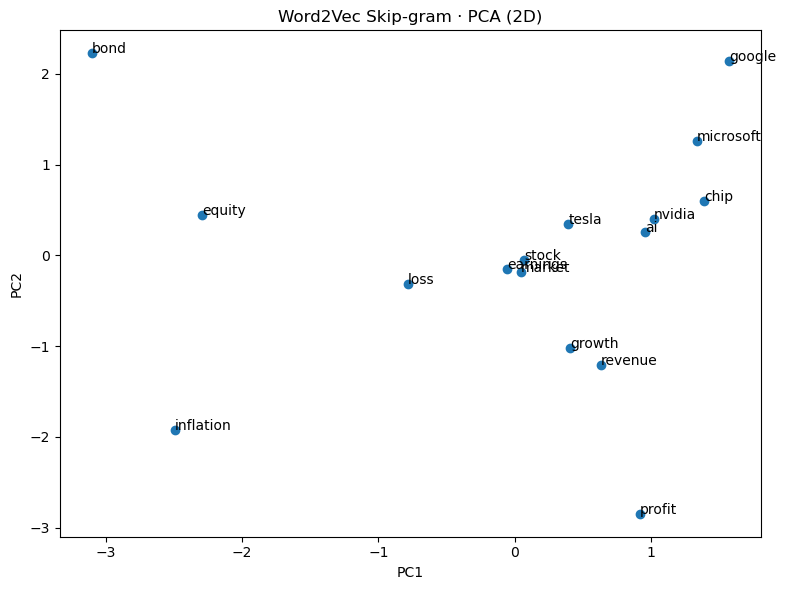

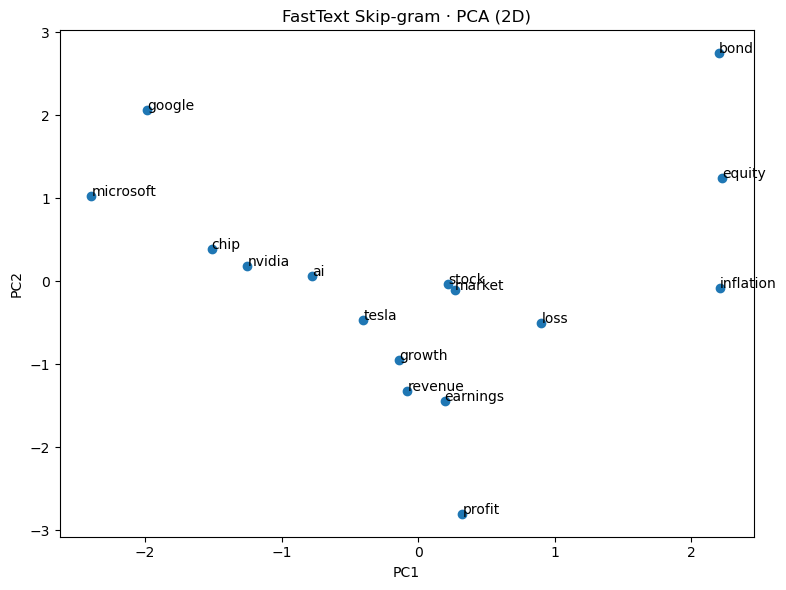

In [11]:

def plot_embeddings_2d(model, words, title="Embeddings 2D (PCA)"):
    found = [w for w in words if w in model.wv.key_to_index]
    if not found:
        print("Ninguna palabra encontrada en el vocabulario para visualizar.")
        return
    X = np.array([model.wv[w] for w in found])
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    X2 = pca.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X2[:,0], X2[:,1])
    for i, w in enumerate(found):
        plt.annotate(w, (X2[i,0], X2[i,1]))
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

WORDS_VIZ = [
    "market","stock","bond","equity","ai","chip","nvidia",
    "microsoft","google","tesla","inflation","rates","growth",
    "revenue","profit","loss","earnings"
]

plot_embeddings_2d(w2v_sg, WORDS_VIZ, title="Word2Vec Skip-gram · PCA (2D)")
plot_embeddings_2d(ft_sg, WORDS_VIZ, title="FastText Skip-gram · PCA (2D)")


- La reducción PCA del modelo Word2Vec confirma una alineación semántica entre términos del mismo campo, como *market–stock–equity* o *profit–revenue–growth*. Frente a GloVe, las relaciones aparecen más compactas y ordenadas, lo que indica que el entrenamiento sobre nuestro corpus ha favorecido representaciones más ajustadas al contexto económico.
- El modelo FastText proyectado con PCA presenta una estructura más distribuida, pero mantiene coherencia entre grupos de términos financieros. Su capacidad de representar subpalabras permite una mejor cobertura del vocabulario, reflejada en la correcta proximidad entre *inflation*, *rates* y *bond*, y entre *profit*, *revenue* y *earnings*. Esto refuerza su solidez frente a variaciones léxicas en el dominio.



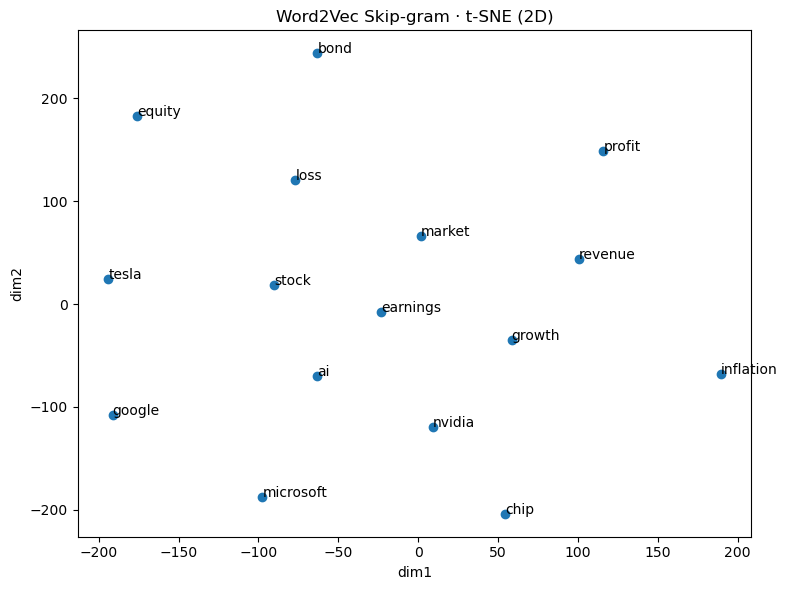

In [12]:

def plot_tsne(model, words, title="t-SNE (2D)"):
    found = [w for w in words if w in model.wv.key_to_index]
    if not found:
        print("Ninguna palabra encontrada en el vocabulario para visualizar.")
        return
    X = np.array([model.wv[w] for w in found])
    tsne = TSNE(n_components=2, random_state=RANDOM_SEED, init='pca', learning_rate='auto', perplexity=min(30, max(5, len(found)//2)))
    X2 = tsne.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X2[:,0], X2[:,1])
    for i, w in enumerate(found):
        plt.annotate(w, (X2[i,0], X2[i,1]))
    plt.title(title)
    plt.xlabel("dim1")
    plt.ylabel("dim2")
    plt.tight_layout()
    plt.show()

plot_tsne(w2v_sg, WORDS_VIZ, title="Word2Vec Skip-gram · t-SNE (2D)")


El modelo Word2Vec (Skip-gram) evidencia una organización más clara y contextualizada, con clusters bien diferenciados entre compañías tecnológicas y términos macroeconómicos. Este comportamiento sugiere que el modelo entrenado sobre nuestro corpus ha capturado relaciones semánticas específicas del lenguaje financiero, diferenciando temas como beneficios, crecimiento o inflación.

## 10. Exportar vectores (KeyedVectors / .kv)

In [13]:

w2v_cbow_kv_path = os.path.join(OUTPUT_DIR, "w2v_cbow.kv")
w2v_sg_kv_path   = os.path.join(OUTPUT_DIR, "w2v_sg.kv")
ft_sg_kv_path    = os.path.join(OUTPUT_DIR, "fasttext_sg.kv")

w2v_cbow.wv.save(w2v_cbow_kv_path)
w2v_sg.wv.save(w2v_sg_kv_path)
ft_sg.wv.save(ft_sg_kv_path)

print("KeyedVectors guardados en:")
print(" -", w2v_cbow_kv_path)
print(" -", w2v_sg_kv_path)
print(" -", ft_sg_kv_path)


KeyedVectors guardados en:
 - embeddings/NoContext\w2v_cbow.kv
 - embeddings/NoContext\w2v_sg.kv
 - embeddings/NoContext\fasttext_sg.kv


## 11. Tabla comparativa de modelos

In [14]:

rows = []
for name, model in [("w2v_cbow", w2v_cbow), ("w2v_sg", w2v_sg), ("ft_sg", ft_sg)]:
    vocab_size = len(model.wv.key_to_index)
    rows.append({
        "modelo": name,
        "vector_size": model.vector_size,
        "window": model.window,
        "min_count": model.min_count,
        "vocab_model": vocab_size,
        "epochs": EPOCHS
    })
pd.DataFrame(rows)


,modelo,vector_size,window,min_count,vocab_model,epochs
0,w2v_cbow,300,5,5,12367,10
1,w2v_sg,300,5,5,12367,10
2,ft_sg,300,5,5,12367,10



## GloVe

Utilizamos el modelo preentrenado `glove.6B.300d` para disponer de una referencia generalista y evaluar la diferencia frente a modelos entrenados sobre nuestro corpus financiero. Aunque no se ajusta específicamente a nuestro dominio, nos permite medir el impacto del contexto financiero sobre la semántica de las representaciones.


In [ ]:
# Rutas
OUTPUT_DIR = "embeddings/NoContext/"
GLOVE_TXT = "data/external/glove.6B.300d.txt"
W2V_OUT   = f"{OUTPUT_DIR}/glove.6B.300d.word2vec.txt"
INPUT_DATA_PATH = "datasPost_prepro/preprocNoContext.parquet"
TEXT_COLUMN = "noContextText"

# Parámetros
RANDOM_SEED = 42

In [27]:

import os, numpy as np, pandas as pd
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [28]:

def load_corpus(path, text_col):
    if path.endswith(".parquet"):
        df = pd.read_parquet(path)
    elif path.endswith(".csv"):
        df = pd.read_csv(path)
    else:
        raise ValueError("Formato no soportado. Usa .parquet o .csv")
    if text_col not in df.columns:
        raise KeyError(f"La columna '{text_col}' no existe en el dataset. Columnas: {list(df.columns)[:10]}...")
    return df[[text_col]].dropna().rename(columns={text_col: "text"})

try:
    df = load_corpus(INPUT_DATA_PATH, TEXT_COLUMN)
    sentences_tokens = [t for t in df["text"].str.split().tolist() if t]
    print("Registros:", len(df), "| ejemplo de tokens:", sentences_tokens[0][:20] if len(sentences_tokens)>0 else [])
except Exception as e:
    print("Aviso: no se pudo cargar el corpus. Solo se hará análisis interno de GloVe.")
    sentences_tokens = None

Registros: 5160 | ejemplo de tokens: ['uk', 'job', 'market', 'continue', 'sign', 'weakness', 'pay', 'growth', 'slowing', 'unemployment', 'edge', 'higher', 'ahead', 'autumn', 'budget', 'month', 'late', 'datum', 'office', 'national']


In [29]:

# Convertir (solo una vez)
if not os.path.exists(W2V_OUT):
    print("Convirtiendo GloVe a formato word2vec...")
    glove2word2vec(GLOVE_TXT, W2V_OUT)
    print("Conversión OK:", W2V_OUT)
else:
    print("Conversión ya existente:", W2V_OUT)

# Cargar
glove_kv = KeyedVectors.load_word2vec_format(W2V_OUT, binary=False)
print("Vocab GloVe:", len(glove_kv.key_to_index))

Conversión ya existente: embeddings/NoContext//glove.6B.300d.word2vec.txt
Vocab GloVe: 400000


In [ ]:
def corpus_vocab_and_oov(sentences, kv):
    vocab = set(kv.key_to_index.keys())
    total_tokens = 0
    in_vocab = 0
    for sent in sentences or []:
        for tok in sent:
            total_tokens += 1
            if tok in vocab:
                in_vocab += 1
    oov = total_tokens - in_vocab
    return {
        "unique_vocab_model": len(vocab),
        "total_tokens_corpus": total_tokens,
        "in_vocab_tokens": in_vocab,
        "oov_tokens": oov,
        "oov_pct": 100.0 * oov / max(total_tokens, 1)
    }

if sentences_tokens is not None:
    glove_stats = corpus_vocab_and_oov(sentences_tokens, glove_kv)
    display(pd.DataFrame([glove_stats], index=["glove.6B.300d"]))
else:
    print("omitir.")

,unique_vocab_model,total_tokens_corpus,in_vocab_tokens,oov_tokens,oov_pct
glove.6B.300d,400000,1308468,1277702,30766,2.351299


Evaluamos la coherencia semántica del espacio vectorial calculando las palabras más similares a términos clave como *market*, *inflation* o *profit*. Este análisis nos permite comprobar si los modelos han capturado relaciones económicas reales y si las proximidades reflejan patrones coherentes de co-ocurrencia dentro del dominio.

In [31]:
EXAMPLES = ["market","stock","revenue","profit","ai","inflation","nasdaq","federal","reserve","interest","rate"]

def try_most_similar_kv(kv, words, topn=10):
    out = {}
    for w in words:
        if w in kv.key_to_index:
            out[w] = kv.most_similar(w, topn=topn)
        else:
            out[w] = [("**OOV**", 0.0)]
    return out

sim_glove = try_most_similar_kv(glove_kv, EXAMPLES, topn=10)
for w, lst in sim_glove.items():
    print(f"\n{w}:")
    for t, s in lst[:10]:
        print("  ", t, f"{s:.3f}")


market:
   markets 0.830
   stock 0.674
   prices 0.657
   investors 0.646
   stocks 0.608
   selling 0.606
   price 0.595
   trading 0.594
   marketplace 0.593
   buying 0.586

stock:
   shares 0.753
   stocks 0.717
   market 0.674
   exchange 0.653
   trading 0.635
   nasdaq 0.630
   investors 0.622
   share 0.610
   markets 0.588
   index 0.581

revenue:
   revenues 0.889
   profits 0.678
   earnings 0.661
   profit 0.644
   income 0.636
   sales 0.627
   billion 0.598
   operating 0.575
   tax 0.568
   increase 0.560

profit:
   profits 0.844
   earnings 0.766
   pretax 0.724
   net 0.680
   revenue 0.644
   sales 0.619
   quarter 0.616
   gains 0.611
   revenues 0.594
   share 0.587

ai:
   sugiyama 0.582
   n’t 0.504
   gonna 0.502
   nothin 0.491
   hey 0.460
   anymore 0.457
   'cause 0.453
   miyazato 0.436
   weiwei 0.430
   fukuhara 0.428

inflation:
   inflationary 0.684
   rate 0.654
   rates 0.645
   unemployment 0.631
   growth 0.602
   slowing 0.595
   deflation 0.586


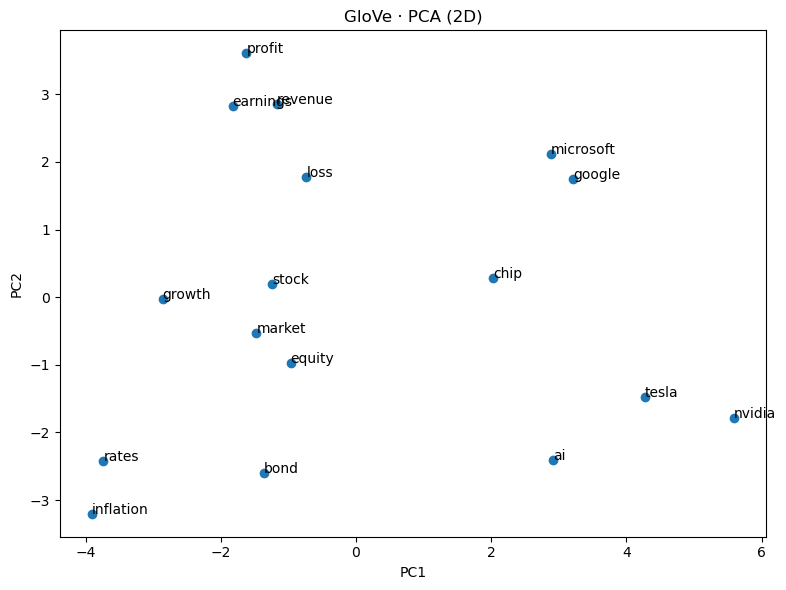

In [32]:
WORDS_VIZ = ["market","stock","bond","equity","ai","chip","nvidia","microsoft","google","tesla","inflation","rates","growth","revenue","profit","loss","earnings"]

def plot_embeddings_2d_kv(kv, words, title="GloVe · PCA (2D)"):
    found = [w for w in words if w in kv.key_to_index]
    if not found:
        print("Ninguna palabra encontrada en el vocabulario para visualizar.")
        return
    X = np.array([kv[w] for w in found])
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    X2 = pca.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(X2[:,0], X2[:,1])
    for i, w in enumerate(found):
        plt.annotate(w, (X2[i,0], X2[i,1]))
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout(); plt.show()

plot_embeddings_2d_kv(glove_kv, WORDS_VIZ, title="GloVe · PCA (2D)")

En este caso GloVe muestra una estructura coherente entre términos del dominio económico, agrupando conceptos relacionados como *market*, *stock* y *equity*, o *profit*, *revenue* y *earnings*. Sin embargo, se observa una menor cohesión en los términos tecnológicos (*google*, *microsoft*, *ai*), lo que refleja la naturaleza generalista del modelo preentrenado frente a nuestro corpus financiero.
